ARSITEKTUR CNN

INPUT
1 × 28 × 28
     │
     ▼
Conv2D
1 → 32 filter
     │
     ▼
ReLU
     │
     ▼
MaxPooling
     │
     ▼
Conv2D
32 → 64 filter
     │
     ▼
ReLU
     │
     ▼
MaxPooling
     │
     ▼
Flatten
     │
     ▼
Fully Connected
1600 → 100
     │
     ▼
ReLU
     │
     ▼
Output
100 → 10
     │
     ▼
0 1 2 3 4 5 6 7 8 9




In [ ]:
# ============================================================
# CELL 1
# INSTALL LIBRARY
# ============================================================

# Kode ini digunakan jika praktikum dijalankan
# menggunakan Google Colab.

import subprocess

try:

    # Mengecek apakah program berjalan di Google Colab
    import google.colab

    # Menginstall library Skorch
    subprocess.run([
        'python',
        '-m',
        'pip',
        'install',
        '-q',
        'skorch'
    ])

except ImportError:

    # Jika tidak menggunakan Google Colab,
    # bagian ini tidak melakukan apa-apa.
    pass

In [ ]:
# ============================================================
# CELL 2
# IMPORT LIBRARY
# ============================================================

# Digunakan untuk mengambil dataset MNIST
from sklearn.datasets import fetch_openml

# Digunakan untuk membagi data
from sklearn.model_selection import train_test_split

# Digunakan untuk menghitung accuracy
from sklearn.metrics import accuracy_score

# Digunakan untuk membuat confusion matrix
from sklearn.metrics import confusion_matrix

# Digunakan untuk melihat precision, recall, dan F1-score
from sklearn.metrics import classification_report

# Library untuk manipulasi data numerik
import numpy as np

# Library untuk visualisasi
import matplotlib.pyplot as plt

# Library untuk confusion matrix
import seaborn as sns

# Library PyTorch
import torch

# Neural network dari PyTorch
from torch import nn

# Fungsi-fungsi neural network
import torch.nn.functional as F

# Skorch untuk menghubungkan PyTorch dengan scikit-learn
from skorch import NeuralNetClassifier

In [ ]:
# ============================================================
# CELL 3
# MENENTUKAN DEVICE
# ============================================================

# Jika komputer/Google Colab memiliki GPU NVIDIA,
# PyTorch akan menggunakan CUDA.
#
# Jika GPU tidak tersedia,
# program akan menggunakan CPU.

device = (
    'cuda'
    if torch.cuda.is_available()
    else 'cpu'
)

print(
    "Device yang digunakan:",
    device
)

Device yang digunakan: cpu


In [ ]:
# ============================================================
# CELL 4
# LOAD DATASET MNIST
# ============================================================

# Dataset MNIST berisi gambar angka tulisan tangan
# dari 0 sampai 9.
#
# Setiap gambar berukuran:
#
# 28 x 28 pixel
#
# Jumlah kelas:
#
# 10 kelas
# yaitu 0, 1, 2, ..., 9

mnist = fetch_openml(
    'mnist_784',
    as_frame=False,
    cache=False
)

# Menampilkan ukuran dataset
print(
    "Ukuran dataset:",
    mnist.data.shape
)

Ukuran dataset: (70000, 784)


In [ ]:
# ============================================================
# CELL 5
# MEMISAHKAN DATA DAN LABEL
# ============================================================

# X berisi nilai pixel gambar
X = mnist.data.astype(
    'float32'
)

# y berisi label angka
y = mnist.target.astype(
    'int64'
)

print(
    "Shape X:",
    X.shape
)

print(
    "Shape y:",
    y.shape
)

Shape X: (70000, 784)
Shape y: (70000,)


In [ ]:
# ============================================================
# CELL 6
# NORMALISASI DATA
# ============================================================

# Nilai pixel MNIST awalnya berada pada:
#
# 0 sampai 255
#
# Kita ubah menjadi:
#
# 0 sampai 1
#
# Proses ini disebut normalisasi.

X = X / 255.0

print(
    "Nilai minimum:",
    X.min()
)

print(
    "Nilai maksimum:",
    X.max()
)

Nilai minimum: 0.0
Nilai maksimum: 1.0


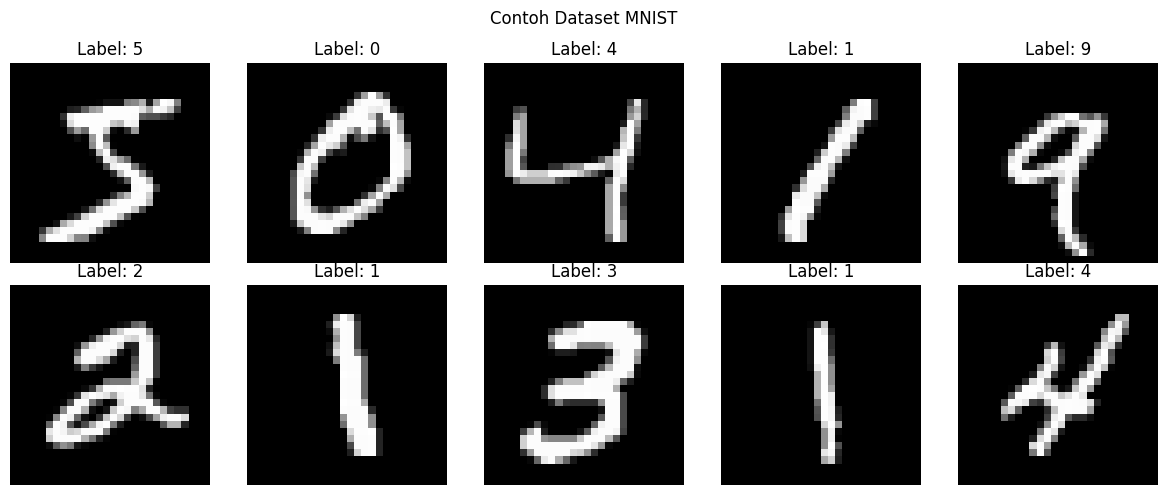

In [ ]:
# ============================================================
# CELL 7
# MENAMPILKAN DATA AWAL MNIST
# ============================================================

# Membuat area gambar
plt.figure(
    figsize=(12, 5)
)

# Menampilkan 10 gambar pertama
for i in range(10):

    # Membuat subplot
    plt.subplot(
        2,
        5,
        i + 1
    )

    # Data masih berbentuk 784 pixel.
    # Kita ubah menjadi 28 x 28.
    image = X[i].reshape(
        28,
        28
    )

    # Menampilkan gambar grayscale
    plt.imshow(
        image,
        cmap='gray'
    )

    # Menampilkan label sebenarnya
    plt.title(
        f"Label: {y[i]}"
    )

    # Menghilangkan sumbu
    plt.axis('off')

plt.suptitle(
    "Contoh Dataset MNIST"
)

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# CELL 8
# MENGUBAH FORMAT DATA UNTUK CNN
# ============================================================

# Sebelumnya:
#
# X.shape
#
# (70000, 784)
#
# CNN membutuhkan:
#
# (jumlah_data, channel, height, width)
#
# sehingga menjadi:
#
# (70000, 1, 28, 28)

X_CNN = X.reshape(
    -1,
    1,
    28,
    28
)

print(
    "Shape data CNN:",
    X_CNN.shape
)

Shape data CNN: (70000, 1, 28, 28)


In [ ]:
# ============================================================
# CELL 9
# MEMBAGI DATA TRAINING DAN TESTING
# ============================================================

# Data dibagi menjadi:
#
# 75% -> training
# 25% -> testing

X_train, X_test, y_train, y_test = train_test_split(
    X_CNN,
    y,
    test_size=0.25,
    random_state=42
)

print(
    "Data training:",
    X_train.shape
)

print(
    "Data testing:",
    X_test.shape
)

print(
    "Label training:",
    y_train.shape
)

print(
    "Label testing:",
    y_test.shape
)

Data training: (52500, 1, 28, 28)
Data testing: (17500, 1, 28, 28)
Label training: (52500,)
Label testing: (17500,)


In [ ]:
# ============================================================
# CELL 10
# CEK DATA
# ============================================================

print(
    "Apakah terdapat NaN?",
    np.isnan(X_train).any()
)

print(
    "Apakah terdapat Inf?",
    np.isinf(X_train).any()
)

print(
    "Nilai minimum:",
    X_train.min()
)

print(
    "Nilai maksimum:",
    X_train.max()
)

print(
    "Kelas:",
    np.unique(y_train)
)

Apakah terdapat NaN? False
Apakah terdapat Inf? False
Nilai minimum: 0.0
Nilai maksimum: 1.0
Kelas: [0 1 2 3 4 5 6 7 8 9]


In [ ]:
# ============================================================
# CELL 11
# ARSITEKTUR CNN
# ============================================================

class CNN(nn.Module):

    def __init__(
        self,
        dropout=0.5
    ):

        # Memanggil constructor PyTorch
        super().__init__()

        # ====================================================
        # CONVOLUTION LAYER 1
        # ====================================================

        # Input:
        # 1 channel
        #
        # Karena MNIST adalah grayscale.
        #
        # Output:
        # 32 feature maps
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=3
        )

        # ====================================================
        # CONVOLUTION LAYER 2
        # ====================================================

        # Input:
        # 32 feature maps
        #
        # Output:
        # 64 feature maps
        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3
        )

        # ====================================================
        # DROPOUT
        # ====================================================

        # Dropout digunakan untuk membantu mengurangi
        # overfitting.
        self.dropout = nn.Dropout2d(
            p=dropout
        )

        # ====================================================
        # FULLY CONNECTED LAYER
        # ====================================================

        # Setelah convolution dan pooling,
        # feature map memiliki ukuran:
        #
        # 64 x 5 x 5
        #
        # sehingga jumlah neuron:
        #
        # 64 x 5 x 5 = 1600

        self.fc1 = nn.Linear(
            1600,
            100
        )

        # ====================================================
        # OUTPUT LAYER
        # ====================================================

        # MNIST mempunyai 10 kelas:
        #
        # 0 sampai 9

        self.fc2 = nn.Linear(
            100,
            10
        )

    def forward(self, x):

        # ====================================================
        # CONVOLUTION 1
        # ====================================================

        x = self.conv1(x)

        # ReLU digunakan sebagai activation function
        x = F.relu(x)

        # Max Pooling
        #
        # Mengurangi ukuran feature map.
        x = F.max_pool2d(
            x,
            2
        )

        # ====================================================
        # CONVOLUTION 2
        # ====================================================

        x = self.conv2(x)

        # ReLU
        x = F.relu(x)

        # Dropout
        x = self.dropout(x)

        # Max Pooling
        x = F.max_pool2d(
            x,
            2
        )

        # ====================================================
        # FLATTEN
        # ====================================================

        # Feature map diubah menjadi vector
        # sebelum masuk Fully Connected Layer.

        x = x.view(
            x.size(0),
            -1
        )

        # ====================================================
        # FULLY CONNECTED
        # ====================================================

        x = self.fc1(x)

        # ReLU
        x = F.relu(x)

        # Dropout
        x = F.dropout(
            x,
            training=self.training
        )

        # ====================================================
        # OUTPUT
        # ====================================================

        # Menghasilkan 10 logits.
        #
        # Tidak menggunakan softmax di sini karena
        # CrossEntropyLoss akan menanganinya.

        x = self.fc2(x)

        return x

In [ ]:
# ============================================================
# CELL 12
# MENAMPILKAN ARSITEKTUR CNN
# ============================================================

# Membuat objek model
model = CNN()

# Menampilkan struktur model
print(model)

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (dropout): Dropout2d(p=0.5, inplace=False)
  (fc1): Linear(in_features=1600, out_features=100, bias=True)
  (fc2): Linear(in_features=100, out_features=10, bias=True)
)


In [ ]:
# ============================================================
# CELL 13
# MEMBUAT CNN CLASSIFIER
# ============================================================

# Menentukan seed
torch.manual_seed(0)

# Membuat classifier menggunakan Skorch
cnn = NeuralNetClassifier(

    # Model CNN
    CNN,

    # Jumlah epoch
    max_epochs=10,

    # Learning rate
    lr=0.001,

    # Optimizer Adam
    optimizer=torch.optim.Adam,

    # Loss function
    criterion=torch.nn.CrossEntropyLoss,

    # Ukuran batch
    batch_size=128,

    # Menggunakan GPU atau CPU
    device=device
)

In [ ]:
# ============================================================
# CELL 14
# TRAINING CNN
# ============================================================

print(
    "===== MEMULAI TRAINING CNN ====="
)

cnn.fit(
    X_train,
    y_train
)

print(
    "===== TRAINING SELESAI ====="
)

===== MEMULAI TRAINING CNN =====
  epoch    train_loss    valid_acc    valid_loss      dur
-------  ------------  -----------  ------------  -------
      1        0.5207       0.9679        0.1056  38.4582
      2        0.1756       0.9780        0.0716  37.9648
      3        0.1401       0.9810        0.0627  38.5762
      4        0.1145       0.9830        0.0546  38.4377
      5        0.1064       0.9832        0.0520  38.2639
      6        0.0971       0.9875        0.0456  38.0296
      7        0.0894       0.9869        0.0449  37.8054
      8        0.0797       0.9878        0.0414  40.5775
      9        0.0764       0.9876        0.0423  37.2239
     10        0.0713       0.9880        0.0382  37.3136
===== TRAINING SELESAI =====


In [ ]:
# ============================================================
# CELL 15
# PREDIKSI DATA TESTING
# ============================================================

# Model melakukan prediksi terhadap
# data yang belum digunakan untuk training.

y_pred = cnn.predict(
    X_test
)

print(
    "10 label sebenarnya:"
)

print(
    y_test[:10]
)

print(
    "\n10 hasil prediksi:"
)

print(
    y_pred[:10]
)

10 label sebenarnya:
[8 4 8 7 7 0 6 2 7 4]

10 hasil prediksi:
[8 4 8 7 7 0 6 2 7 4]


In [ ]:
# ============================================================
# CELL 16
# ACCURACY CNN
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    f"Accuracy CNN: "
    f"{accuracy * 100:.2f}%"
)

Accuracy CNN: 98.74%


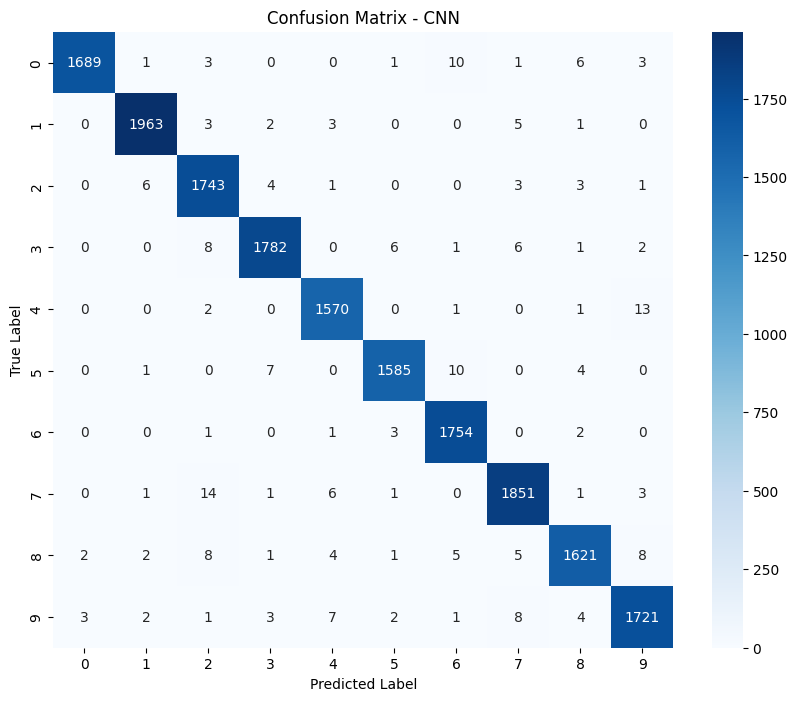

In [ ]:
# ============================================================
# CELL 17
# CONFUSION MATRIX
# ============================================================

# Membuat confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

# Membuat ukuran gambar
plt.figure(
    figsize=(10, 8)
)

# Menampilkan confusion matrix
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)

plt.title(
    "Confusion Matrix - CNN"
)

plt.show()

In [ ]:
# ============================================================
# CELL 18
# CLASSIFICATION REPORT
# ============================================================

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1714
           1       0.99      0.99      0.99      1977
           2       0.98      0.99      0.98      1761
           3       0.99      0.99      0.99      1806
           4       0.99      0.99      0.99      1587
           5       0.99      0.99      0.99      1607
           6       0.98      1.00      0.99      1761
           7       0.99      0.99      0.99      1878
           8       0.99      0.98      0.98      1657
           9       0.98      0.98      0.98      1752

    accuracy                           0.99     17500
   macro avg       0.99      0.99      0.99     17500
weighted avg       0.99      0.99      0.99     17500



Jumlah prediksi benar: 17279


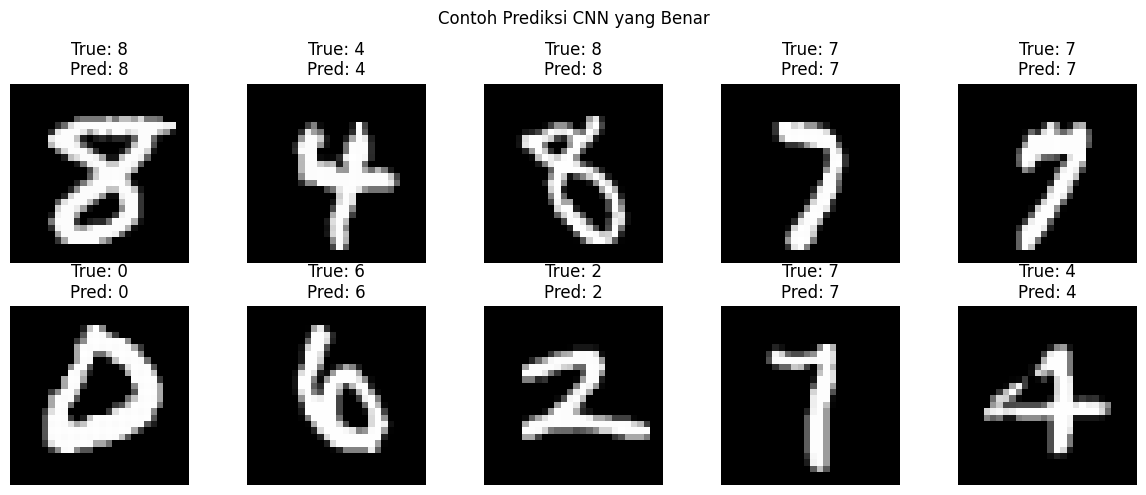

In [ ]:
# ============================================================
# CELL 19
# PREDIKSI BENAR
# ============================================================

# Mencari index gambar yang berhasil
# diklasifikasikan dengan benar.

correct_indices = np.where(
    y_pred == y_test
)[0]

print(
    "Jumlah prediksi benar:",
    len(correct_indices)
)

# Menampilkan maksimal 10 gambar
plt.figure(
    figsize=(12, 5)
)

for i in range(
    min(10, len(correct_indices))
):

    # Mengambil index
    index = correct_indices[i]

    # Mengambil gambar
    image = X_test[index]

    # Karena gambar memiliki 1 channel,
    # kita mengambil channel pertama.
    image = image[0]

    # Membuat subplot
    plt.subplot(
        2,
        5,
        i + 1
    )

    # Menampilkan gambar
    plt.imshow(
        image,
        cmap='gray'
    )

    # Menampilkan label asli dan prediksi
    plt.title(
        f"True: {y_test[index]}\n"
        f"Pred: {y_pred[index]}"
    )

    plt.axis('off')

plt.suptitle(
    "Contoh Prediksi CNN yang Benar"
)

plt.tight_layout()

plt.show()

Jumlah prediksi salah: 221


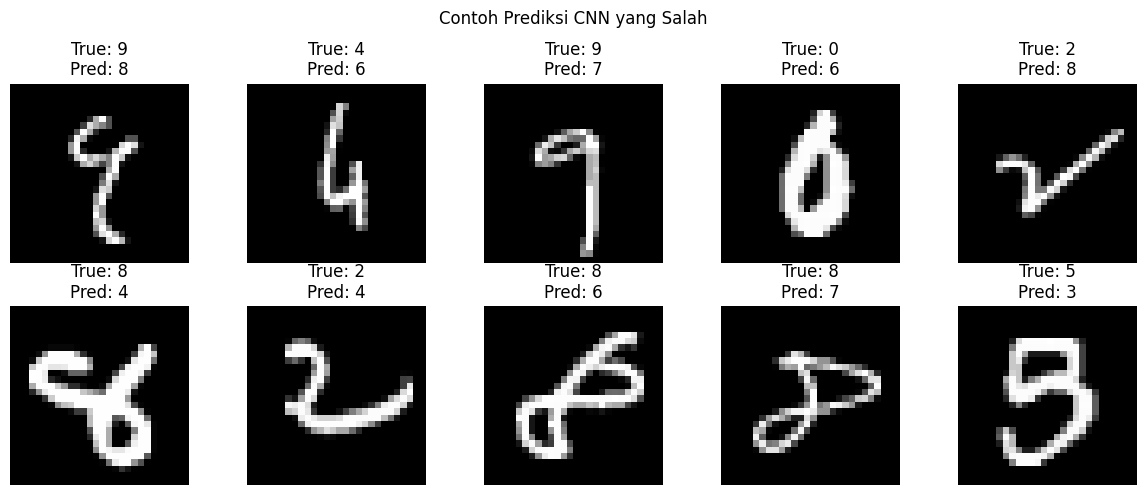

In [ ]:
# ============================================================
# CELL 20
# PREDIKSI SALAH
# ============================================================

# Mencari index gambar yang salah
# diklasifikasikan oleh model.

wrong_indices = np.where(
    y_pred != y_test
)[0]

print(
    "Jumlah prediksi salah:",
    len(wrong_indices)
)

# Menampilkan maksimal 10 gambar
plt.figure(
    figsize=(12, 5)
)

for i in range(
    min(10, len(wrong_indices))
):

    # Mengambil index
    index = wrong_indices[i]

    # Mengambil gambar
    image = X_test[index]

    # Mengambil channel grayscale
    image = image[0]

    # Membuat subplot
    plt.subplot(
        2,
        5,
        i + 1
    )

    # Menampilkan gambar
    plt.imshow(
        image,
        cmap='gray'
    )

    # Menampilkan label sebenarnya
    # dan hasil prediksi model.
    plt.title(
        f"True: {y_test[index]}\n"
        f"Pred: {y_pred[index]}"
    )

    plt.axis('off')

plt.suptitle(
    "Contoh Prediksi CNN yang Salah"
)

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# CELL 21
# FUNGSI PREDIKSI SATU GAMBAR
# ============================================================

def predict_image(
    model,
    images,
    labels,
    index
):

    # Mengambil satu gambar
    image = images[index]

    # Mengubah bentuk menjadi:
    #
    # (1, 1, 28, 28)
    #
    # 1 pertama = jumlah gambar
    # 1 kedua  = channel

    input_image = np.expand_dims(
        image,
        axis=0
    )

    # Melakukan prediksi
    prediction = model.predict(
        input_image
    )

    # Mengambil hasil prediksi
    predicted_label = prediction[0]

    # Label sebenarnya
    true_label = labels[index]

    # Menampilkan gambar
    plt.figure(
        figsize=(5, 5)
    )

    plt.imshow(
        image[0],
        cmap='gray'
    )

    plt.title(
        f"True Label : {true_label}\n"
        f"Prediction : {predicted_label}"
    )

    plt.axis('off')

    plt.show()

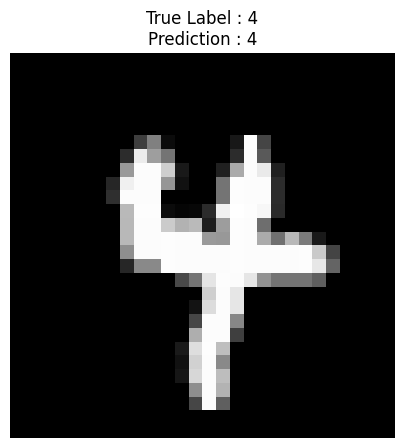

In [ ]:
# ============================================================
# CELL 22
# MENCOBA PREDIKSI
# ============================================================

# Contoh:
# kita ingin melihat gambar testing ke-100

predict_image(
    cnn,
    X_test,
    y_test,
    1
)

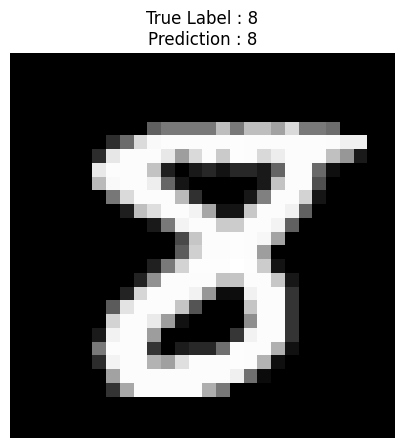

In [ ]:
# ============================================================
# CELL 23
# MENAMPILKAN SATU PREDIKSI BENAR
# ============================================================

# Mengambil index pertama dari prediksi benar
index_benar = correct_indices[0]

# Menampilkan hasil
predict_image(
    cnn,
    X_test,
    y_test,
    index_benar
)

Kesimpulan :
ANN langsung bekerja pada vector pixel, sedangkan CNN terlebih dahulu mempelajari pola/fitur spasial melalui convolution dan pooling sebelum melakukan klasifikasi.